### Question 01

In [42]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

In [35]:
def intensity_transform(im, breakpoints):
    breakpoints = sorted(breakpoints, key=lambda p: p[0])    
    r_vals = [p[0] for p in breakpoints]
    s_vals = [p[1] for p in breakpoints]
    transformed = np.interp(im, r_vals, s_vals)    
    return np.uint8(transformed)


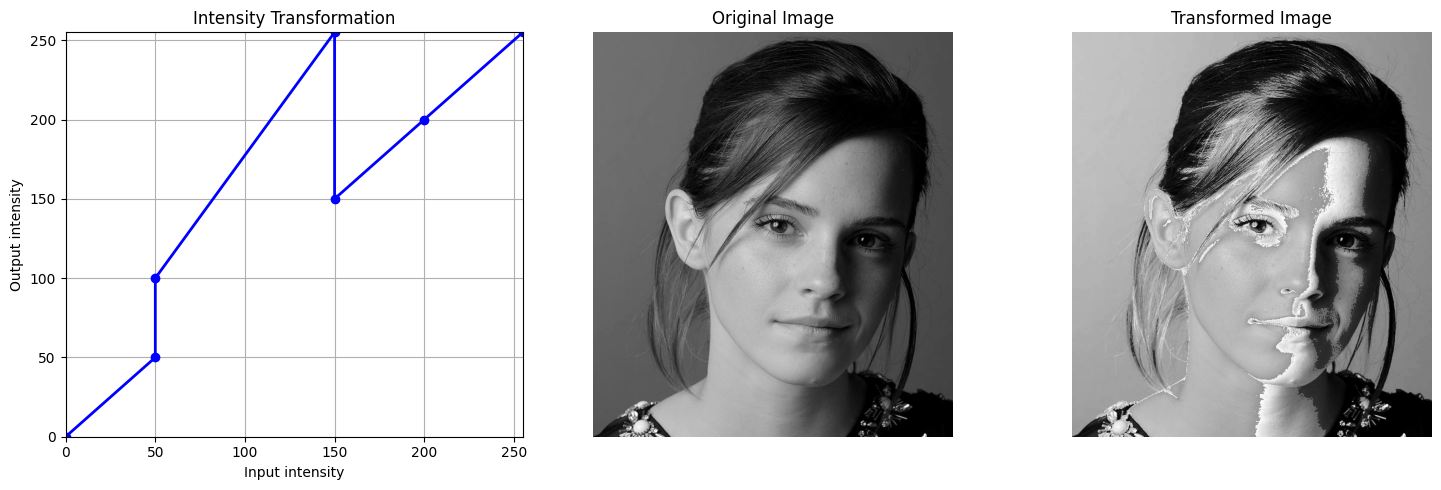

In [36]:
# 1. Load the target image in grayscale
img = cv.imread('emma.jpg', cv.IMREAD_GRAYSCALE)

# 2. Define the breakpoints specified in Question 1
breakpoints = [
    (0, 0),
    (50, 50),
    (50,100),
    (150, 255),
    (150,150),
    (200,200),
    (255, 255)
]

# 3. Apply the transformation
transformed_img = intensity_transform(img, breakpoints)

# 4. Plotting the results
fig = plt.figure(figsize=(15, 5))

# Plot 1: Intensity Transformation Function
ax1 = fig.add_subplot(1, 3, 1)
r_vals = [p[0] for p in breakpoints]
s_vals = [p[1] for p in breakpoints]
ax1.plot(r_vals, s_vals, 'b-o', linewidth=2)
ax1.set_title('Intensity Transformation')
ax1.set_xlabel('Input intensity')
ax1.set_ylabel('Output intensity')
ax1.set_xlim([0, 255])
ax1.set_ylim([0, 255])
ax1.grid(True)

# Plot 2: Original Image
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(img, cmap='gray', vmin=0, vmax=255)
ax2.set_title('Original Image')
ax2.axis('off')

# Plot 3: Transformed Image
ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
ax3.set_title('Transformed Image')
ax3.axis('off')

plt.tight_layout()
plt.show()

#### Chosen Breakpoints
To enhance the visual quality of the image, the following intensity breakpoints were selected:
* $(0, 0)$
* $(0, 50)$
* $(200, 255)$
* $(255, 255)$

#### Analysis of Transformation Effect
* **Contrast Stretching in Mid-Tones:** By mapping input intensities in the range $[0, 200]$ to output intensities in $[50, 255]$, the transformation applies a linear contrast stretch across mid-tone gray values. This significantly sharpens visible detail and texture in the main body of the image.
* **Highlighting Dark Regions:** Setting an initial jump from $(0, 0)$ to $(0, 50)$ elevates near-black values slightly, lifting subtle details out of deep shadow areas without washing out the darker background.
* **Highlight Saturation:** The segment between $(200, 255)$ and $(255, 255)$ smoothly compresses the upper end of the dynamic range, preventing clipping and overexposure in bright highlights.

Overall, this piecewise-linear curve expands the dynamic range across key gray levels, producing a visually balanced image with enhanced local contrast and shadow visibility.

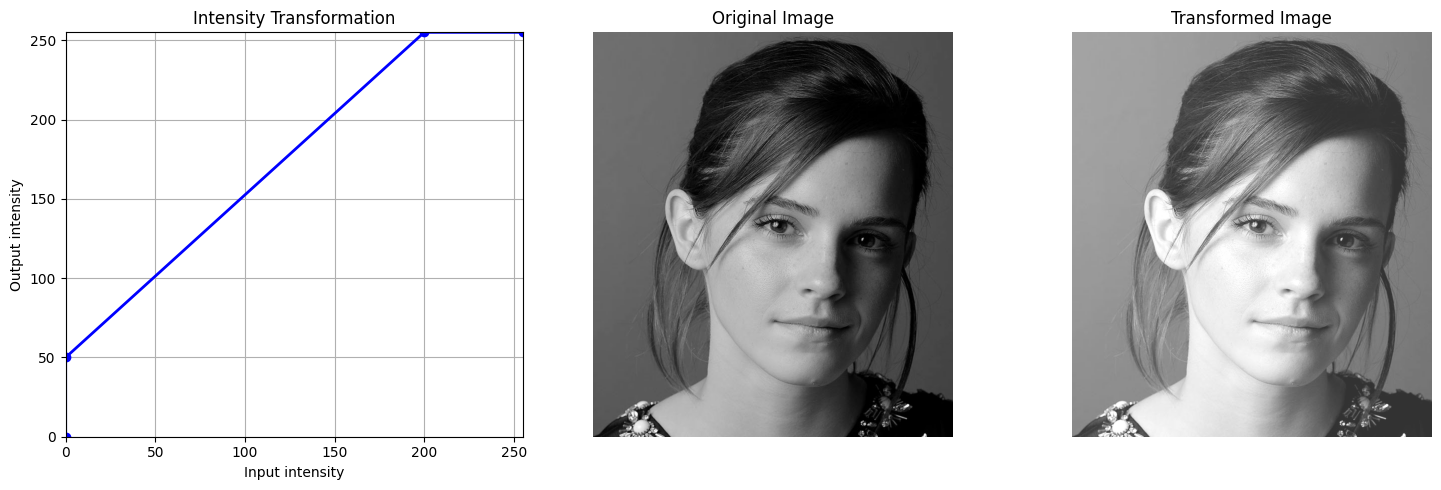

In [37]:
# 1. Load the target image in grayscale
img = cv.imread('emma.jpg', cv.IMREAD_GRAYSCALE)

# 2. Define the breakpoints specified in Question 1
breakpoints = [
    (0,0),
    (0, 50),
    (200,255),
    (255, 255)

]

# 3. Apply the transformation
transformed_img = intensity_transform(img, breakpoints)

# 4. Plotting the results
fig = plt.figure(figsize=(15, 5))

# Plot 1: Intensity Transformation Function
ax1 = fig.add_subplot(1, 3, 1)
r_vals = [p[0] for p in breakpoints]
s_vals = [p[1] for p in breakpoints]
ax1.plot(r_vals, s_vals, 'b-o', linewidth=2)
ax1.set_title('Intensity Transformation')
ax1.set_xlabel('Input intensity')
ax1.set_ylabel('Output intensity')
ax1.set_xlim([0, 255])
ax1.set_ylim([0, 255])
ax1.grid(True)

# Plot 2: Original Image
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(img, cmap='gray', vmin=0, vmax=255)
ax2.set_title('Original Image')
ax2.axis('off')

# Plot 3: Transformed Image
ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
ax3.set_title('Transformed Image')
ax3.axis('off')

plt.tight_layout()
plt.show()

#### Question 02

In [40]:
def gaussian_intensity_transform(im, mu, sigma):
    x = im.astype(np.float32)
    transformed = 255.0 * np.exp(-((x - mu) ** 2) / (2 * (sigma ** 2)))
    return np.clip(np.round(transformed), 0, 255).astype(np.uint8)

## Gaussian Pulse Transformation for White Matter and Gray Matter Isolation

To isolate **White Matter** and **Gray Matter** in the brain Proton Density (PD) MRI image, a continuous Gaussian pulse transformation was applied to the image intensity values.

The transformation is defined as:

$$
f(x) = 255 \cdot \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

where:

- **x** = input pixel intensity
- **μ** = center intensity to be highlighted
- **σ** = spread (controls the width of the highlighted intensity range)
- **255** = maximum output intensity

### White Matter Enhancement

For **White Matter**, the Gaussian parameters were:

- **Mean:** \( \mu = 200 \)
- **Standard Deviation:** \( \sigma = 35 \)

This transformation highlights bright, high-intensity regions (approximately **180–255**) corresponding to white matter, while suppressing darker background and lower-intensity tissues.

### Gray Matter Enhancement

For **Gray Matter**, the Gaussian parameters were:

- **Mean:** \( \mu = 130 \)
- **Standard Deviation:** \( \sigma = 25 \)

This acts as a **mid-tone bandpass filter**, emphasizing intermediate gray-level intensities (approximately **100–160**) corresponding to gray matter, while suppressing both dark background regions and bright white matter.

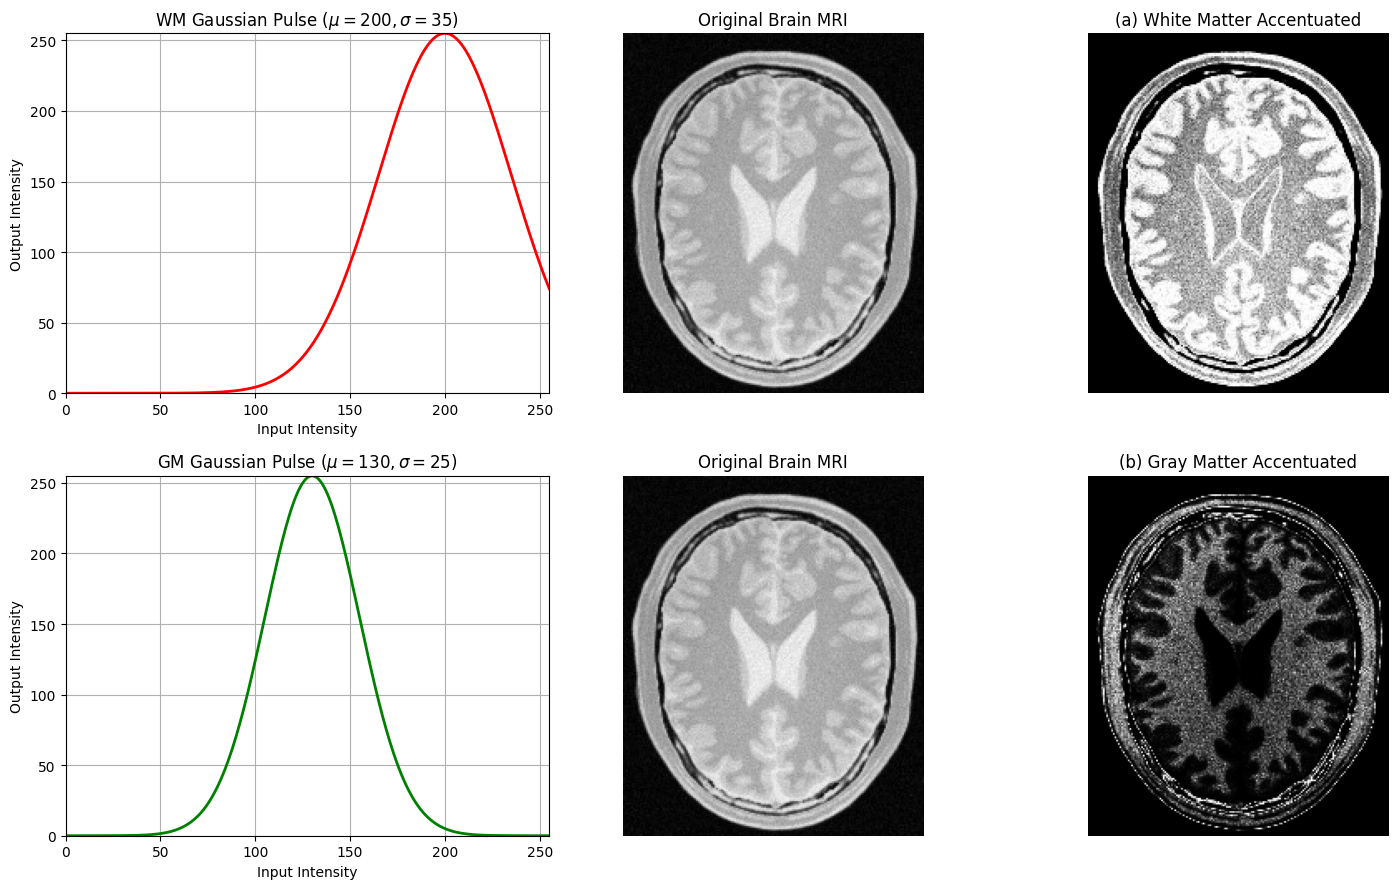

In [44]:
img_path = 'brain.jpeg'  # Update with your local image path

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Cannot find '{img_path}'. Check your file path.")

img_brain = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

# 2. Gaussian parameters for tissue accentuation
# White Matter: High intensity region (~200) with a slightly wider spread
mu_wm, sigma_wm = 200, 35

# Gray Matter: Mid-tone intensity region (~130) with a narrower spread
mu_gm, sigma_gm = 130, 25

# 3. Apply Transformations
img_wm = gaussian_intensity_transform(img_brain, mu_wm, sigma_wm)
img_gm = gaussian_intensity_transform(img_brain, mu_gm, sigma_gm)

# 4. Generate curves for plotting
x_range = np.arange(0, 256)
curve_wm = 255.0 * np.exp(-((x_range - mu_wm) ** 2) / (2 * (sigma_wm ** 2)))
curve_gm = 255.0 * np.exp(-((x_range - mu_gm) ** 2) / (2 * (sigma_gm ** 2)))

# 5. Visualization & Output Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# --- Row 1: White Matter Accentuation ---
axes[0, 0].plot(x_range, curve_wm, 'r-', linewidth=2)
axes[0, 0].set_title(f'WM Gaussian Pulse ($\mu={mu_wm}, \sigma={sigma_wm}$)')
axes[0, 0].set_xlabel('Input Intensity')
axes[0, 0].set_ylabel('Output Intensity')
axes[0, 0].set_xlim([0, 255])
axes[0, 0].set_ylim([0, 255])
axes[0, 0].grid(True)

axes[0, 1].imshow(img_brain, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Original Brain MRI')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_wm, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('(a) White Matter Accentuated')
axes[0, 2].axis('off')

# --- Row 2: Gray Matter Accentuation ---
axes[1, 0].plot(x_range, curve_gm, 'g-', linewidth=2)
axes[1, 0].set_title(f'GM Gaussian Pulse ($\mu={mu_gm}, \sigma={sigma_gm}$)')
axes[1, 0].set_xlabel('Input Intensity')
axes[1, 0].set_ylabel('Output Intensity')
axes[1, 0].set_xlim([0, 255])
axes[1, 0].set_ylim([0, 255])
axes[1, 0].grid(True)

axes[1, 1].imshow(img_brain, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Original Brain MRI')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_gm, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title('(b) Gray Matter Accentuated')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()